This notebook plots some statistics of the atmospheric turbulence.

In [1]:
from lsst.ts.aos.analysis.atmStatUtils import AtmZkStat

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from lsst.ts.wep.utils import convertZernikesToPsfWidth

First let's compare Kolmogorov and von Karman structure functions.
You can see the latter plateaus around the corresponding outer scale of turbulence.

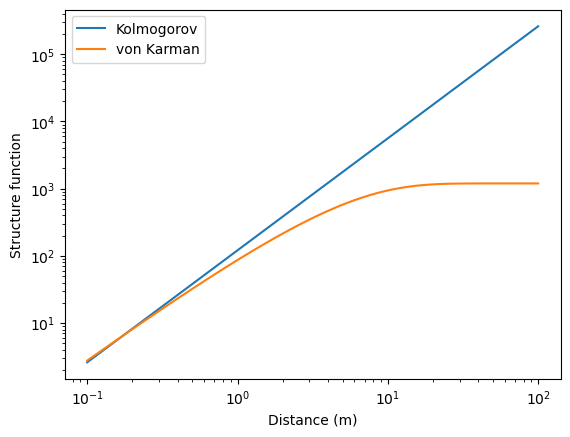

In [10]:
fig, ax = plt.subplots()

r = np.geomspace(1e-1, 100, 100)

stat = AtmZkStat()

# Kolmogorov
stat.L0 = np.inf
ax.plot(r, stat.structure(r), label="Kolmogorov")

# van Karman
stat.L0 = 30
ax.plot(r, stat.structure(r), label="von Karman")

ax.set(xscale="log", yscale="log", xlabel="Distance (m)", ylabel="Structure function")
ax.legend()

plt.show()

Now let's plot the Zernike covariance for a single line of sight.

In [56]:
stat = AtmZkStat()
zk_cov = stat.zk_cov()

# Convert m^2 -> um^2
zk_cov *= 1e6 ** 2

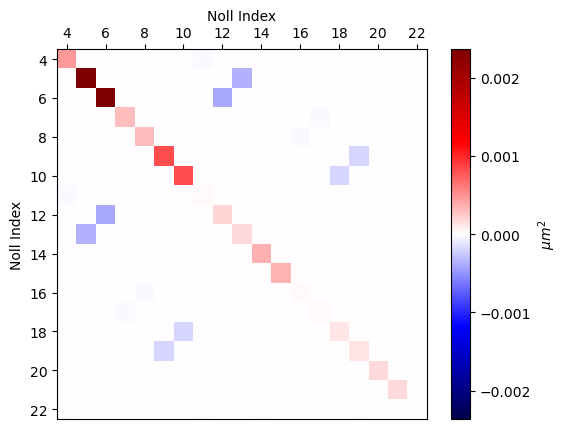

In [57]:
fig, ax = plt.subplots()

vmax = np.abs(zk_cov).max()
img = ax.imshow(
    zk_cov,
    extent=(3.5, 22.5, 3.5, 22.5),
    vmin=-vmax,
    vmax=+vmax,
    cmap="seismic",
)
fig.colorbar(img, label="$\\mu m^2$")

ax.set(
    xticks=np.arange(4, 23, 2),
    yticks=np.arange(4, 23, 2),
    yticklabels=np.arange(4, 23, 2)[::-1],
    xlabel="Noll Index",
    ylabel="Noll Index",
)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

plt.show()

and the standard deviation of each Zernike:

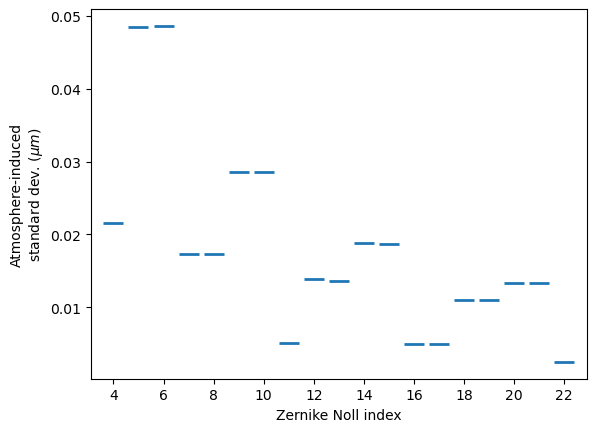

In [58]:
fig, ax = plt.subplots()

zk_std = np.sqrt(np.diag(zk_cov))
ax.scatter(
    np.arange(4, 23),
    zk_std,
    marker="_",
    s=200,
    lw=2,
)
ax.set(
    xlabel="Zernike Noll index",
    xticks=np.arange(4, 23, 2),
    ylabel="Atmosphere-induced\nstandard dev. ($\\mu m$)",
)

plt.show()

Now let's investigate the cross-covariance for different angular separations.
(note currently the module assumes the atmospheric covariance is isotropic. I am planning to relax this assumption in future studies)

In [69]:
thetas = [0, 1, 2, 4, 8]
theta_covs = []
for theta in thetas:
    # Set separation angle
    stat.theta = theta

    # Save in micron^2
    theta_covs.append(stat.zk_cov() * 1e6 ** 2)

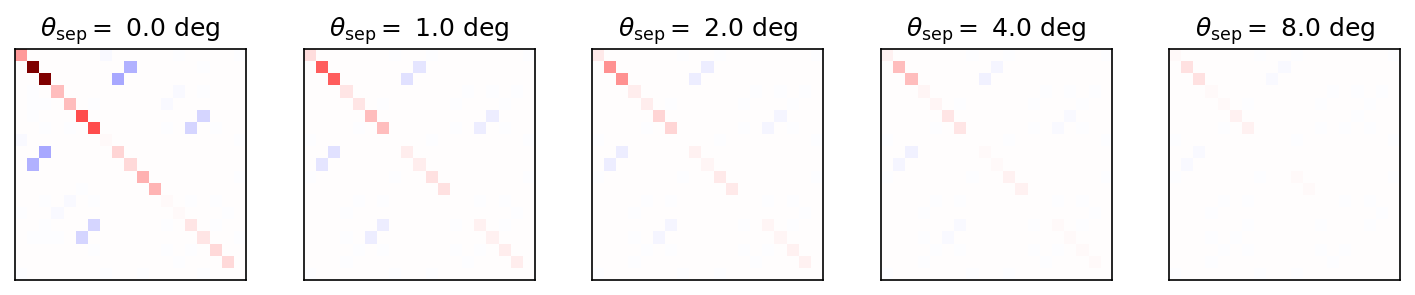

In [71]:
fig, axes = plt.subplots(1, 5, figsize=(12, 2), dpi=150)

for i, theta in enumerate(thetas):
    axes[i].imshow(
        theta_covs[i],
        vmin=-vmax,
        vmax=+vmax,
        cmap="seismic",
    )
    axes[i].set(
        xticks=[],
        yticks=[],
        title=f"$\\theta_\\mathrm{{sep}} =$ {theta:.1f} deg",
    )

plt.show()

Finally we will calculate the correlation in Zernike noise as a function of angular separation:

In [132]:
# Calculate Pearson correlation as a function of separation
thetas = np.geomspace(1e-2, 3.5, 20)
theta_corr = []
sigX_sigY = np.outer(zk_std, zk_std)
for theta in thetas:
    # Set separation angle
    stat.theta = theta

    # covariance in micron^2
    cov = stat.zk_cov() * 1e6 ** 2

    # Calculate correlation
    corr = cov / sigX_sigY

    # Save Frobenius norm
    theta_corr.append(np.sqrt(np.sum(np.square(corr))))

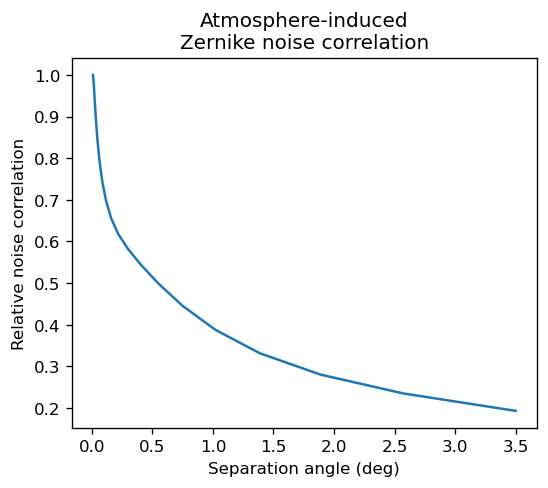

In [133]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)

ax.plot(thetas, np.divide(theta_corr, theta_corr[0]))
ax.set(
    xlabel="Separation angle (deg)",
    ylabel="Relative noise correlation",
    title="Atmosphere-induced\nZernike noise correlation",
)

plt.show()

Plotting with a log scale on the x-axis, we can see the correlation is decaying exponentially:

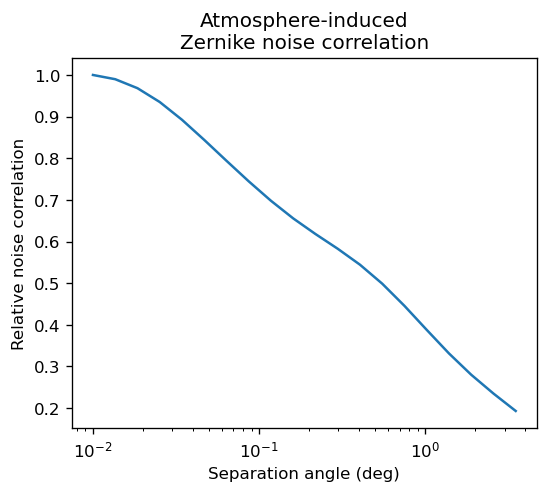

In [135]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=120)

ax.plot(thetas, np.divide(theta_corr, theta_corr[0]))
ax.set(
    xlabel="Separation angle (deg)",
    ylabel="Relative noise correlation",
    title="Atmosphere-induced\nZernike noise correlation",
    xscale="log",
)

plt.show()

We can see the characteristic length is $\sim 0.75^\mathrm{o}$

In [143]:
from scipy.stats import linregress
linregress(np.log(thetas), theta_corr)

LinregressResult(slope=np.float64(-0.7493264581780532), intercept=np.float64(2.0390609597510068), rvalue=np.float64(-0.997436553474867), pvalue=np.float64(4.49731552253162e-22), stderr=np.float64(0.012670628648257463), intercept_stderr=np.float64(0.030959627067257016))